<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day2/ExercisesXP_Diabetes_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercises XP - Diabetes Classification

## What you will learn
- Understanding the problem
- Data collection
- Model training for classification
- Model evaluation

## What you will create
- A Logistic Regression model to predict diabetes



## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

- Load the diabetes dataset and explore it
- Count positive and negative cases
- Split the data into train and test


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/diabetes_prediction_dataset.csv')

print(df.shape)
display(df.head())
print(df.dtypes)
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
Missing per column:


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [7]:
# Assume target column is named 'diabetes' with 0 or 1 values
assert 'diabetes' in df.columns, "Expected a 'diabetes' target column"
print(df['diabetes'].value_counts())


diabetes
0    91500
1     8500
Name: count, dtype: int64


In [8]:
# train test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=['diabetes'])
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(80000, 8) (20000, 8)



## Exercise 2 - Model picking and standardization

- Which model can we use and why
- Do we need to standardize
- If yes, apply StandardScaler


### Justification de la Régression Logistique
La régression logistique est idéale pour cette tâche de classification binaire car elle modélise directement la probabilité d'appartenance à une classe via la fonction sigmoïde. Elle offre une **frontière de décision linéaire** simple et une grande **interprétabilité** (les coefficients indiquent l'importance de facteurs comme l'HbA1c).

La **standardisation** est essentielle ici car les variables numériques ont des échelles très différentes (ex: l'âge vs le taux de glucose). Cela assure une convergence plus rapide de l'algorithme et empêche les variables à forte magnitude de dominer indûment le calcul des poids.

In [9]:
# build a preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['gender', 'smoking_history']
Numeric: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


## Exercise 3 - Model training

In [4]:
# train Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

clf = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'HbA1c_level',
                                                   'blood_glucose_level'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


## Exercise 4 - Evaluation metrics

- Plot accuracy and comment
- Plot confusion matrix and comment
- Plot precision, recall, F1 and comment


Accuracy: 0.9605
Precision: 0.8587
Recall: 0.64
F1: 0.7334


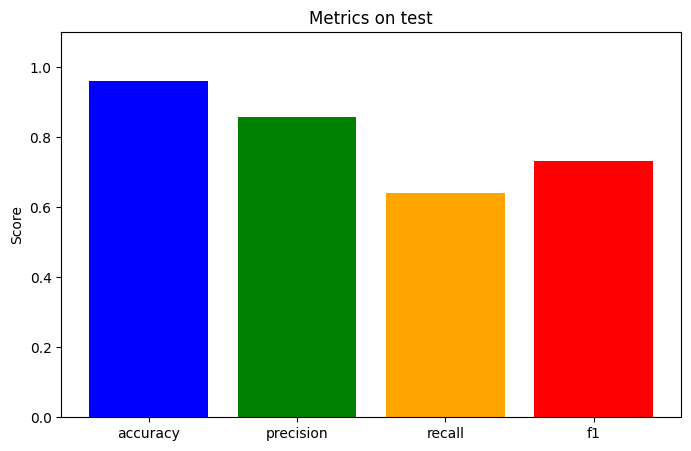

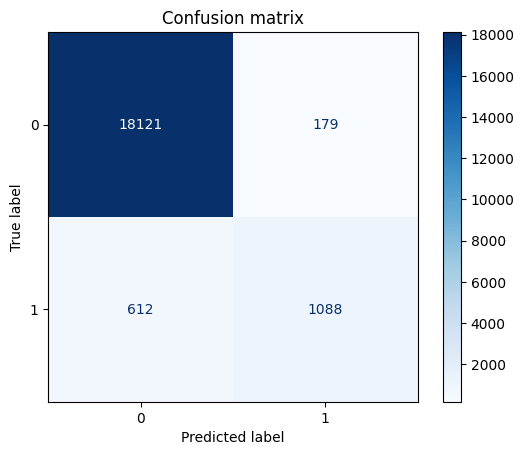

In [10]:
# use the metrics functions properly to plot the scores
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1:", round(f1,4))

# Simple bar plot of metrics
plt.figure(figsize=(8, 5))
plt.bar(['accuracy','precision','recall','f1'], [acc,prec,rec,f1], color=['blue', 'green', 'orange', 'red'])
plt.title('Metrics on test')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix')
plt.show()

### Interprétation des Métriques
Bien que l'exactitude (**Accuracy**) soit élevée (96%), l'analyse du **Rappel (0.64)** et de la **Précision (0.86)** est plus révélatrice :
- La précision est bonne : quand le modèle prédit un diabète, il a raison dans 86% des cas.
- Le rappel est plus faible : le modèle ne détecte que 64% des cas réels de diabète.

Dans un contexte médical, un faux négatif (oublier un malade) est souvent plus grave qu'un faux positif. Il serait donc intéressant d'ajuster le seuil de décision pour augmenter le rappel, même si cela diminue un peu la précision.


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy info. Use only two informative features for this plot to keep it 2D. Suggested pair: `HbA1c_level` and `blood_glucose_level` if present. Otherwise pick any two numeric features.


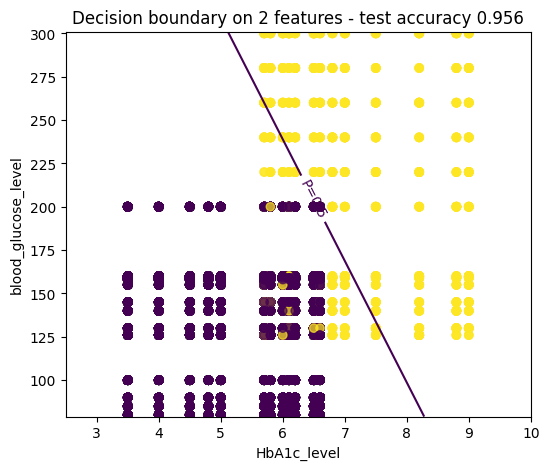

In [14]:
# TODO: If these columns do not exist, change `feat_x` and `feat_y` below to two numeric features that exist in your data.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

feat_x = 'HbA1c_level' if 'HbA1c_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[0]
feat_y = 'blood_glucose_level' if 'blood_glucose_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[1]

X2_train = X_train[[feat_x, feat_y]].copy()
X2_test = X_test[[feat_x, feat_y]].copy()

pipe2 = Pipeline([
    ('pre', ColumnTransformer([('num', StandardScaler(), [0,1])], remainder='drop')),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
pipe2.fit(X2_train.values, y_train)

# Mesh
x_min, x_max = X2_train[feat_x].min()-1, X2_train[feat_x].max()+1
y_min, y_max = X2_train[feat_y].min()-1, X2_train[feat_y].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
probs = pipe2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

plt.figure(figsize=(6,5))
cs = plt.contour(xx, yy, probs, levels=[0.5])
# Fix: use single curly braces for dictionary
plt.clabel(cs, inline=True, fmt={0.5:'P=0.5'})
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test, alpha=0.7)
plt.xlabel(feat_x); plt.ylabel(feat_y)
from sklearn.metrics import accuracy_score
acc2 = accuracy_score(y_test, pipe2.predict(X2_test.values))
plt.title(f'Decision boundary on 2 features - test accuracy {acc2:.3f}')
plt.show()


## Exercise 6 - ROC curve

Use the code template provided to plot the ROC curve for your model and compute AUC. You can reuse the fitted `clf` pipeline.

Template summary:
- Get predicted probabilities for the positive class
- Compute fpr and tpr with `roc_curve`
- Plot ROC and print AUC


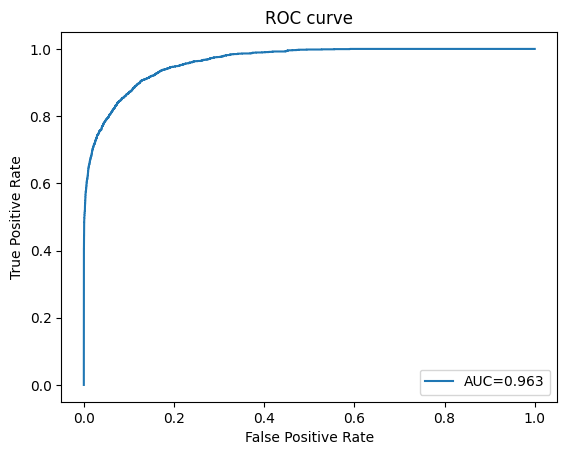

In [13]:

from sklearn import metrics
y_proba = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)
auc = metrics.roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.title('ROC curve')
plt.show()


### Interprétation de la courbe ROC et de l'AUC
La courbe ROC montre la performance du modèle à différents seuils. Notre score **AUC de 0.963** est excellent (proche de 1). Cela signifie qu'il y a plus de 96% de chances que le modèle classe correctement un individu malade choisi au hasard par rapport à un individu sain. La forme de la courbe, qui monte très vite vers le coin supérieur gauche, confirme que le modèle sépare très efficacement les deux classes, principalement grâce aux variables `HbA1c_level` et `blood_glucose_level`.